<a href="https://colab.research.google.com/github/isaacadebayo/MSDS-570/blob/main/Isaac_Adebayo_MSDS570_HW_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## MSDS 570 Visualization and Unstructured Data Analysis
## Homework Assignment 2: Introduction to Matplotlib and Seaborn

###  Due March 5, 2026 (11.50 pm CST)                              
### Total 100 points

## Homework Submission instructions
To submit this homework:
- Please create a new notebook named as <b>Name_MSDS570_HW#2</b>.
- Please write your solutions and submit the notebook files on Blackboard or email me if facing issues in submitting the notebook file.
- Assignments <b> MUST </b> be submitted on time.
- This programming assignment <b>should be done individually</b>. You can discuss the problems but the codes should not be same.
- Late submission policy will be applied for the late submissions
- Feedbacks will be provided in your solution notebook below the questions

## Problem 1 (25 Points)

Given the `tips dataset` for a restaurant as shown in below code:

In [ ]:
import seaborn as sns
df = sns.load_dataset('tips')
df.head(5)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


- You are the owner of a restaurant and, due to a new
law, you have to introduce a `No Smoking Day`.
- To make as few
losses as possible, you want to `visualize how many sales are
made every day, categorized by smokers and non-smokers`:

1) Use the given dataset and create a
matrix where the elements contain
the sum of the total bills for each
day and smokers/non-smokers.

2) Create a stacked bar plot, stacking
the summed total bills separated by
smoker and non-smoker for each
day. Add a legend, labels, and a
title.

3) After executing the preceding steps,
the expected output should be as
follows:

REMEMBER TO REMOVE THE SUBMISSION INSTRUCTION TO TRANSFROM INTO A NEW NOTEBOOK

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
df1 = df.copy()
df_sum = df1['total_bill'].copy()
# sum because it is a numerical column
df_sum = df1.groupby(['smoker', 'day'])['total_bill'].sum()
df_sum



/tmp/ipykernel_133243/521053747.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_sum = df1.groupby(['smoker', 'day'])['total_bill'].sum()


smoker  day 
Yes     Thur     326.24
        Fri      252.20
        Sat      893.62
        Sun      458.28
No      Thur     770.09
        Fri       73.68
        Sat      884.78
        Sun     1168.88
Name: total_bill, dtype: float64

In [ ]:
df2 = df.copy()
# slicing df2 to retrieve smoking status
df_sum2 = df1['smoker'].copy()
df_sum2 = df1['smoker'].value_counts()
df_sum2
#df_sum2.value_counts()

,count
smoker,
No,151
Yes,93


In [ ]:
df3 = df.copy()
# slicing df3 to retrieve days
df_sum3 = df1['day'].copy()
df_sum3 = df1['day'].value_counts()
df_sum3



,count
day,
Sat,87
Sun,76
Thur,62
Fri,19


In [ ]:
# Convert series into dataframe

merged_df = df_sum.to_frame(name='total_bill')
merged_df2 = df_sum2.to_frame(name='smoker')
merged_df3 = df_sum3.to_frame(name='day')

In [ ]:
#merged_df_sum= concat_df.groupby(['smoker', 'day'])['total_bill'].sum()
# sum because it is a numerical column
total_bill_sum = concat_df.groupby(['smoker', 'day'])['total_bill'].sum()
#total_bill_sum.info()

day_sum = concat_df['day'].value_counts()
day_sum.info()

smoker_sum = concat_df['smoker'].value_counts()
smoker_sum.info()


<class 'pandas.core.series.Series'>
Index: 4 entries, 87.0 to 19.0
Series name: count
Non-Null Count  Dtype
--------------  -----
4 non-null      int64
dtypes: int64(1)
memory usage: 64.0 bytes
<class 'pandas.core.series.Series'>
Index: 2 entries, 151.0 to 93.0
Series name: count
Non-Null Count  Dtype
--------------  -----
2 non-null      int64
dtypes: int64(1)
memory usage: 32.0 bytes


/tmp/ipykernel_133243/2571481634.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_smoker_bills = df.groupby(['day', 'smoker'])['total_bill'].sum().unstack(level='smoker')


<Figure size 1920x1440 with 0 Axes>

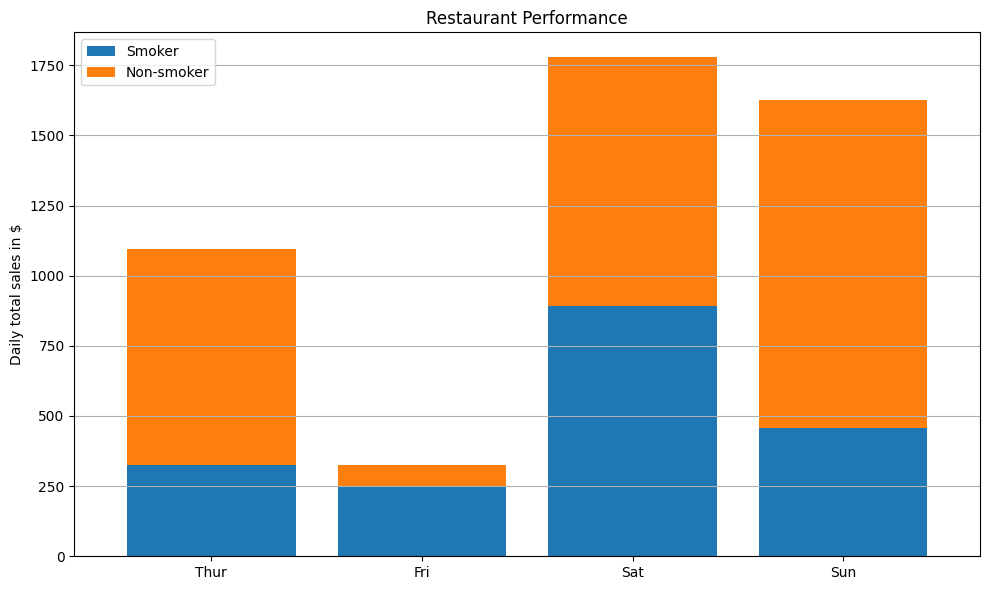

<Figure size 1920x1440 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd # Ensure pandas is imported


daily_smoker_bills = df.groupby(['day', 'smoker'])['total_bill'].sum().unstack(level='smoker')

# Rename columns for better legend labels
daily_smoker_bills.rename(columns={'Yes': 'Smoker', 'No': 'Non-smoker'}, inplace=True)

# 2. Create a stacked bar plot.
ax = daily_smoker_bills.plot(kind='bar', stacked=True, figsize=(10, 6), width = 0.8)

# Add a legend, labels, and a title.
ax.set_title('Restaurant Performance')
ax.set_xlabel('')
ax.set_ylabel('Daily total sales in $')
ax.legend(loc='upper left')

# Add major horizontal grid with solid lines
ax.yaxis.grid(which='major')

# Add minor horizontal grid with dashed lines
ax.yaxis.grid(which='minor', linestyle='--')

# Rotate x-axis labels if needed (days are short, usually not necessary)
plt.xticks(rotation=0)

# Display the plot
plt.tight_layout();
plt.figure(dpi=300)

## Problem 2 (25 Points)

Given the `tips dataset` for a restaurant as shown in below code:

1) Use the appropriate visualization technique to plot `total_bill` and add appropriate legend and title in the plot.

2) Use pie chart to visualize the distribution of `time` and `sex` [Plot different pie charts for both variables]

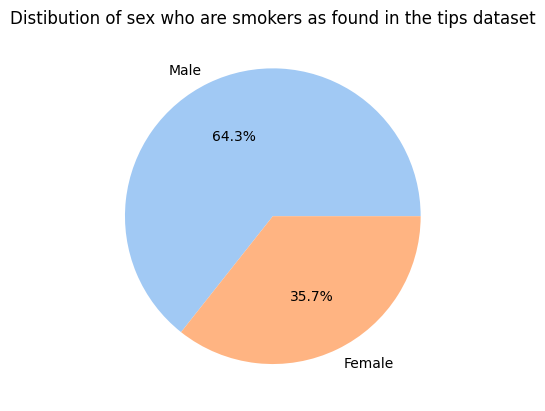

In [ ]:
import seaborn as sns
df = sns.load_dataset('tips')
df.head()

counts = df['sex'].value_counts()
counts

plt.pie(counts, labels=counts.index, colors=sns.color_palette('pastel'), autopct='%1.1f%%')
plt.title('Distibution of sex who are smokers as found in the tips dataset')
plt.show()

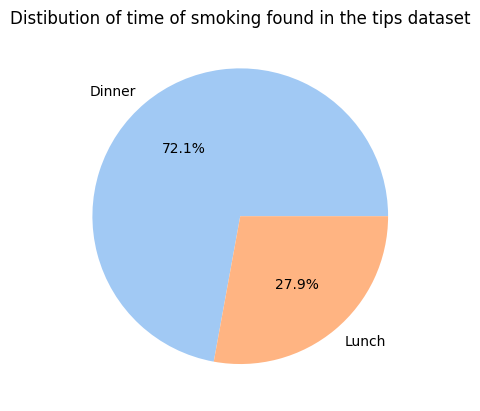

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
data = sns.load_dataset('tips')
data.head()
counts = df['time'].value_counts()
counts

plt.pie(counts, labels=counts.index, colors=sns.color_palette('pastel'), autopct='%1.1f%%')
plt.title('Distibution of time of smoking found in the tips dataset')

plt.show()


 **Seaborn package does not include pie chart at least the one I have on Colab, pie chart will be done with matplotlib
matplotlib does not plot the categorical data asked which is time and sex. So my best guess is that we have to use count (as per gemini)
and then label each variable explicitly to get an understanding of the count(my intuition)**

**I also tried to create a new cell and load the tip dataset but I was unable to. The dataset is stuck on that specific cell which i find odd
since it ask for two pie charts.**

**NOTE FOR MYSELF
"DIFFERNCE BETWEEN DATAFRAME AND SERIES. DATAFRAME IS FOR MULTIPLE COLUMN THINK THE WHOLE EXCEL SHEET WHILE SERIES IS FOR SINGLE COLUMN, THINK A COLUMN IN EXCEL. DATAFRAME INFO IS GOTTEN USING 'df.info()', WHILE SERIES INFOR IS GOTTEN USING 's.info()'. SERIES IS 1D , WHILE DATAFRAME IS IN 2D. SLICING DATAFRAME RETURNS A WORD ON A COLUMN, WHILE SLICING SERIES RETURNS A CHARACTER. SERIEEES USES '.value_counts()' TO DETERMINE THE AMOUNT OF TIMES A VALUE APPEAR IN A ROW. WHEN SHOULD I USE DATAFRAME OR SERIES, COMPLEX RELATIONSHIP USE DATAFRAME WITH MULTIPLE ROWS AND COLUMNS, SIMPLE ATTRIBUTE USE SERIES"**

A pie chart represents parts of a single whole, which is why it inherently maps to the 1D structure of a Series.


## Problem 3 (50 Points)

1) Use pandas to read the data file `flights_details.csv` uploaded on blackboard. The given
dataset contains the monthly figures
for flight passengers from the years
2001 to 2012.

2) Use a heatmap to visualize the
given data.

3) Use your own color map. Make
sure that the lowest value is the
darkest color and that the highest
value is the brightest color.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<Axes: xlabel='Years', ylabel='Months'>

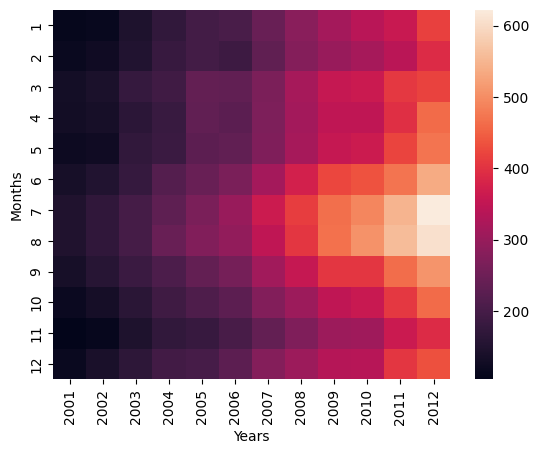

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('/content/drive/MyDrive/flight_details.csv')
data

#Conversion of categorical variable (month) to numerical variable (int or float)
# January = 1, February = 2, March = 3, April = 4, May = 5, June = 6, July = 7, August = 8, September = 9, October = 10, November = 11, December = 12

# Dictionary to create the legend
#data_conv_legend = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6, 'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}

data_conv = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6, 'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}
data['Months'] = data['Months'].map(data_conv)
data

# Turn long format into a wide format
df_wide = data.pivot_table(index='Months', columns='Years', values='Passengers')

# plot heatmap using seaborn
sns.heatmap(df_wide)

In [ ]:
'''#Conversion of categorical variable (month) to numerical variable (int or float) using dictionary
data_conv = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6, 'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}
data['Months'] = data['Months'].map(data_conv)
data'''

"#Conversion of categorical variable (month) to numerical variable (int or float) using dictionary\ndata_conv = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6, 'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}\ndata['Months'] = data['Months'].map(data_conv)\ndata"

**NOTE TO SELF: Seaborn and matplotlib but work with both datatypes (categorical and numerical). However the values inside a heatmap has to be numerical and does not apply to categorical variables. For the flight_details.csv dataset, there contain categorical variable under the column months that needs to be converted to numerical variable before plotting an heatmap**

<Axes: xlabel='Years', ylabel='Months'>

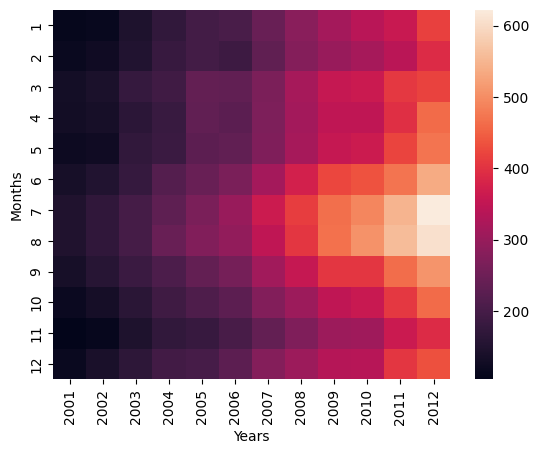

In [ ]:
# Turn long format into a wide format
df_wide = data.pivot_table(index='Months', columns='Years', values='Passengers')

# plot heatmap using seaborn
sns.heatmap(df_wide)


**CONCEPT REVIEW: The difference between a list and a dicitionary. A list is an ordered sequence indexed by position (numbers), while a dictionary is a collection of key-value pairs indexed by unique labels (keys). List is accessed using a numerical name e.g.,(list[0]), dicitionary is accessed using a unique key e.g., (dict['name']) (values cant be repeated in a dictionary). According to gemini "a Python list is heterogeneous, meaning it can hold any combination of data types at the same time—strings (categorical), integers (numerical), floats, or even other lists". So lets give it a try on my code. Why not?.**